In [1]:
import os, gc, warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, f1_score,
    accuracy_score, precision_score, recall_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cpu


In [27]:
CFG = dict(
    DATA_DIR        = '/kaggle/input/datasets/solarmainframe/ids-intrusion-csv',

    # ── Sampling ────────────────────────────────
    MAX_BENIGN      = 300_000,  
    MAX_ATTACK      =  50_000,

    D_MODEL         = 128,        
    NHEAD           = 8,         
    ENC_LAYERS      = 3,         
    DEC_LAYERS      = 2,         
    FFN_DIM         = 256,      
    LATENT_DIM      = 64,        
    GROUP_SIZE      = 8,         
    DROPOUT         = 0.1,

    # ── Training ────────────────────────────────
    BATCH_SIZE      = 1024,
    NUM_EPOCHS      = 50,
    LR              = 1e-3,
    WEIGHT_DECAY    = 1e-4,
    PATIENCE        = 7,
    CLIP_GRAD       = 1.0,
    CLIP_VAL        = 10.0,       

    TARGET_TPR      = 0.90,   
)
print('Config loaded ✓')
for k, v in CFG.items(): print(f'  {k:15s} = {v}')

Config loaded ✓
  DATA_DIR        = /kaggle/input/datasets/solarmainframe/ids-intrusion-csv
  MAX_BENIGN      = 300000
  MAX_ATTACK      = 50000
  D_MODEL         = 128
  NHEAD           = 8
  ENC_LAYERS      = 3
  DEC_LAYERS      = 2
  FFN_DIM         = 256
  LATENT_DIM      = 64
  GROUP_SIZE      = 8
  DROPOUT         = 0.1
  BATCH_SIZE      = 1024
  NUM_EPOCHS      = 50
  LR              = 0.001
  WEIGHT_DECAY    = 0.0001
  PATIENCE        = 7
  CLIP_GRAD       = 1.0
  CLIP_VAL        = 10.0
  TARGET_TPR      = 0.9


In [26]:
import pandas as pd
import numpy as np
import os
import gc

csv_files = sorted([f for f in os.listdir(CFG['DATA_DIR']) if f.endswith('.csv')])
print(f'Found {len(csv_files)} files')

benign_parts, attack_parts = [], []
label_col = None
SAMPLE_FRAC = 0.1 

for fname in csv_files:
    path = os.path.join(CFG['DATA_DIR'], fname)
    try:
        tmp = pd.read_csv(path, low_memory=False)
        tmp.columns = tmp.columns.str.strip()

        if label_col is None:
            for c in tmp.columns:
                if c.lower() in ['label', 'class', 'attack', 'attack_type']:
                    label_col = c
                    break
            if label_col is None: label_col = tmp.columns[-1]

        for col in tmp.columns:
            if tmp[col].dtype == 'float64':
                tmp[col] = tmp[col].astype('float32')
            elif tmp[col].dtype == 'int64':
                tmp[col] = tmp[col].astype('int32')

        benign_mask = tmp[label_col].str.lower().isin(['benign', 'normal'])
        
        b_df = tmp[benign_mask]
        if len(b_df) > 0:
            benign_parts.append(b_df.sample(frac=SAMPLE_FRAC, random_state=42))
            
        a_df = tmp[~benign_mask]
        if len(a_df) > 0:
            attack_parts.append(a_df)

        print(f'  Done: {fname}')
        del tmp, b_df, a_df
        gc.collect()
        
    except Exception as e:
        print(f'  !! Error {fname}: {e}')

df_benign = pd.concat(benign_parts, ignore_index=True)
df_attack = pd.concat(attack_parts, ignore_index=True)

del benign_parts, attack_parts
gc.collect()

print(f'\nTotal benign after sampling: {len(df_benign):,}')
print(f'Total attack: {len(df_attack):,}')

Found 10 files
  Done: 02-14-2018.csv
  Done: 02-15-2018.csv
  Done: 02-16-2018.csv
  Done: 02-20-2018.csv
  Done: 02-21-2018.csv
  Done: 02-22-2018.csv
  Done: 02-23-2018.csv
  Done: 02-28-2018.csv
  Done: 03-01-2018.csv
  Done: 03-02-2018.csv

Total benign after sampling: 1,348,471
Total attack: 2,748,294


In [28]:
def preprocess(df_in, feature_cols=None, fit_cols=True):
    drop = [label_col]
    drop += [c for c in df_in.columns if 'timestamp' in c.lower() or c.lower() == 'time']

    if feature_cols is None:
        cols = [c for c in df_in.columns if c not in drop]
    else:
        cols = feature_cols

    X = df_in[cols].copy().apply(pd.to_numeric, errors='coerce')
    X.replace([np.inf, -np.inf], np.nan, inplace=True)

    if fit_cols:
        bad = X.columns[X.isnull().mean() > 0.5].tolist()
        bad += X.columns[X.std() == 0].tolist()
        X.drop(columns=list(set(bad)), inplace=True)
        cols = list(X.columns)

    return X.values, cols


X_ben_raw, FEAT_COLS = preprocess(df_benign, fit_cols=True)
print(f'Features used: {len(FEAT_COLS)}')

X_att_raw, _ = preprocess(df_attack, feature_cols=FEAT_COLS, fit_cols=False)

ben_medians = np.nanmedian(X_ben_raw, axis=0)
for arr in [X_ben_raw, X_att_raw]:
    nan_mask = np.isnan(arr)
    arr[nan_mask] = np.take(ben_medians, np.where(nan_mask)[1])

print(f'Benign NaN  : {np.isnan(X_ben_raw).sum()}')
print(f'Attack NaN  : {np.isnan(X_att_raw).sum()}')

Features used: 71
Benign NaN  : 0
Attack NaN  : 0


In [29]:
def sample(arr, n):
    if len(arr) <= n: return arr
    idx = np.random.choice(len(arr), n, replace=False)
    return arr[idx]

X_ben = sample(X_ben_raw, CFG['MAX_BENIGN'])
X_att = sample(X_att_raw, CFG['MAX_ATTACK'])
del X_ben_raw, X_att_raw, df_benign, df_attack
gc.collect()

print(f'Benign (sampled): {X_ben.shape}')
print(f'Attack (sampled): {X_att.shape}')

X_tr, X_tmp = train_test_split(X_ben, test_size=0.2, random_state=SEED)
X_bv, X_bt  = train_test_split(X_tmp, test_size=0.5, random_state=SEED)
X_av, X_at  = train_test_split(X_att, test_size=0.5, random_state=SEED)

scaler = RobustScaler(quantile_range=(5, 95))
scaler.fit(X_tr)

def scale_clip(arr):
    out = scaler.transform(arr)
    return np.clip(out, -CFG['CLIP_VAL'], CFG['CLIP_VAL']).astype(np.float32)

X_tr = scale_clip(X_tr)
X_bv = scale_clip(X_bv)
X_bt = scale_clip(X_bt)
X_av = scale_clip(X_av)
X_at = scale_clip(X_at)

INPUT_DIM = X_tr.shape[1]
print(f'\nInput dim  : {INPUT_DIM}')
print(f'Train      : {X_tr.shape}')
print(f'Val benign : {X_bv.shape}  |  Val attack : {X_av.shape}')
print(f'Test benign: {X_bt.shape}  |  Test attack: {X_at.shape}')

Benign (sampled): (300000, 71)
Attack (sampled): (50000, 71)

Input dim  : 71
Train      : (240000, 71)
Val benign : (30000, 71)  |  Val attack : (25000, 71)
Test benign: (30000, 71)  |  Test attack: (25000, 71)


In [32]:
class LiteTAE(nn.Module):
    def __init__(self, input_dim, d_model, nhead, enc_layers,
                 dec_layers, ffn_dim, latent_dim, group_size, dropout):
        super().__init__()
        self.g   = group_size
        self.d   = d_model
        self.lat = latent_dim

        self.pad  = (-input_dim) % group_size
        self.pdim = input_dim + self.pad          
        self.seq  = self.pdim // group_size       
        self.inp  = input_dim

        self.pos = nn.Embedding(self.seq, d_model)

        self.tok_enc = nn.Linear(group_size, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=ffn_dim, dropout=dropout,
            activation='gelu', batch_first=True, norm_first=True
        )
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=enc_layers,
                                         norm=nn.LayerNorm(d_model))
        self.to_lat = nn.Linear(d_model * self.seq, latent_dim)

        self.from_lat = nn.Linear(latent_dim, d_model * self.seq)
        dec_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=ffn_dim, dropout=dropout,
            activation='gelu', batch_first=True, norm_first=True
        )
        self.dec = nn.TransformerEncoder(dec_layer, num_layers=dec_layers,
                                         norm=nn.LayerNorm(d_model))
        self.tok_dec = nn.Linear(d_model, group_size)

        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def _tokenize(self, x):
        B = x.size(0)
        if self.pad > 0:
            x = torch.cat([x, x.new_zeros(B, self.pad)], dim=1)
        return x.view(B, self.seq, self.g)          

    def encode(self, x):
        B = x.size(0)
        t = self._tokenize(x)                       
        h = self.tok_enc(t)                         
        pos = self.pos(torch.arange(self.seq, device=x.device))
        h = h + pos                                 
        h = self.enc(h)                             
        z = self.to_lat(h.reshape(B, -1))           
        return z

    def decode(self, z):
        B = z.size(0)
        h = self.from_lat(z).view(B, self.seq, self.d)  
        pos = self.pos(torch.arange(self.seq, device=z.device))
        h = h + pos
        h = self.dec(h)                             
        out = self.tok_dec(h).reshape(B, -1)        
        return out[:, :self.inp]                   

    def forward(self, x):
        z    = self.encode(x)
        recon = self.decode(z)
        return recon, z


model = LiteTAE(
    input_dim  = INPUT_DIM,
    d_model    = CFG['D_MODEL'],
    nhead      = CFG['NHEAD'],
    enc_layers = CFG['ENC_LAYERS'],
    dec_layers = CFG['DEC_LAYERS'],
    ffn_dim    = CFG['FFN_DIM'],
    latent_dim = CFG['LATENT_DIM'],
    group_size = CFG['GROUP_SIZE'],
    dropout    = CFG['DROPOUT'],
).to(DEVICE)

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters : {params:,}  ({params/1e6:.2f}M)')
print(f'Seq length : {model.seq} tokens')
print(f'Latent dim : {CFG["LATENT_DIM"]}')
print(model)

Parameters : 814,920  (0.81M)
Seq length : 9 tokens
Latent dim : 64
LiteTAE(
  (pos): Embedding(9, 128)
  (tok_enc): Linear(in_features=8, out_features=128, bias=True)
  (enc): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (to_lat): Linear(in_features=1152, out_features=64, bias=True)


In [33]:
def make_loader(arr, batch_size, shuffle=True):
    ds = TensorDataset(torch.from_numpy(arr))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=2, pin_memory=(DEVICE.type=='cuda'))

train_loader = make_loader(X_tr, CFG['BATCH_SIZE'], shuffle=True)
val_loader   = make_loader(X_bv, CFG['BATCH_SIZE'], shuffle=False)

print(f'Train batches : {len(train_loader)}')

criterion = nn.MSELoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=CFG['LR'],
    weight_decay=CFG['WEIGHT_DECAY']
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG['NUM_EPOCHS'],
    eta_min=1e-5
)

amp_scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))
print('Ready ✓')

Train batches : 235
Ready ✓


In [34]:
train_losses, val_losses = [], []
best_val = float('inf')
patience = 0

print(f'Training {CFG["NUM_EPOCHS"]} epochs | batch={CFG["BATCH_SIZE"]} | '
      f'device={DEVICE}')
print('─'*55)

for ep in range(1, CFG['NUM_EPOCHS']+1):

    model.train()
    tr_loss = 0.0
    for (xb,) in train_loader:
        xb = xb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
            recon, _ = model(xb)
            loss = criterion(recon, xb)
        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['CLIP_GRAD'])
        amp_scaler.step(optimizer)
        amp_scaler.update()
        tr_loss += loss.item()

    tr_loss /= len(train_loader)
    train_losses.append(tr_loss)

    model.eval()
    vl_loss = 0.0
    with torch.no_grad():
        for (xb,) in val_loader:
            xb = xb.to(DEVICE)
            recon, _ = model(xb)
            vl_loss += criterion(recon, xb).item()
    vl_loss /= len(val_loader)
    val_losses.append(vl_loss)
    scheduler.step()

    if vl_loss < best_val:
        best_val = vl_loss
        patience = 0
        torch.save(model.state_dict(), '/kaggle/working/best_lite_tae.pt')
    else:
        patience += 1

    if ep % 5 == 0 or ep == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Ep {ep:3d}/{CFG["NUM_EPOCHS"]} | '
              f'train={tr_loss:.5f} | val={vl_loss:.5f} | '
              f'lr={lr_now:.1e} | pat={patience}/{CFG["PATIENCE"]}')

    if patience >= CFG['PATIENCE']:
        print(f'Early stop at epoch {ep}')
        break

model.load_state_dict(torch.load('/kaggle/working/best_lite_tae.pt'))
print(f'\nBest val loss: {best_val:.6f}')

Training 50 epochs | batch=1024 | device=cpu
───────────────────────────────────────────────────────
Ep   1/50 | train=0.13197 | val=0.01294 | lr=1.0e-03 | pat=0/7
Ep   5/50 | train=0.00396 | val=0.00166 | lr=9.8e-04 | pat=0/7
Ep  10/50 | train=0.00185 | val=0.00103 | lr=9.1e-04 | pat=1/7
Ep  15/50 | train=0.00117 | val=0.00066 | lr=8.0e-04 | pat=1/7
Ep  20/50 | train=0.00082 | val=0.00059 | lr=6.6e-04 | pat=1/7
Ep  25/50 | train=0.00058 | val=0.00063 | lr=5.0e-04 | pat=2/7
Ep  30/50 | train=0.00044 | val=0.00029 | lr=3.5e-04 | pat=0/7
Ep  35/50 | train=0.00034 | val=0.00024 | lr=2.1e-04 | pat=0/7
Ep  40/50 | train=0.00028 | val=0.00021 | lr=1.0e-04 | pat=0/7
Ep  45/50 | train=0.00025 | val=0.00019 | lr=3.4e-05 | pat=0/7
Ep  50/50 | train=0.00024 | val=0.00018 | lr=1.0e-05 | pat=0/7

Best val loss: 0.000182


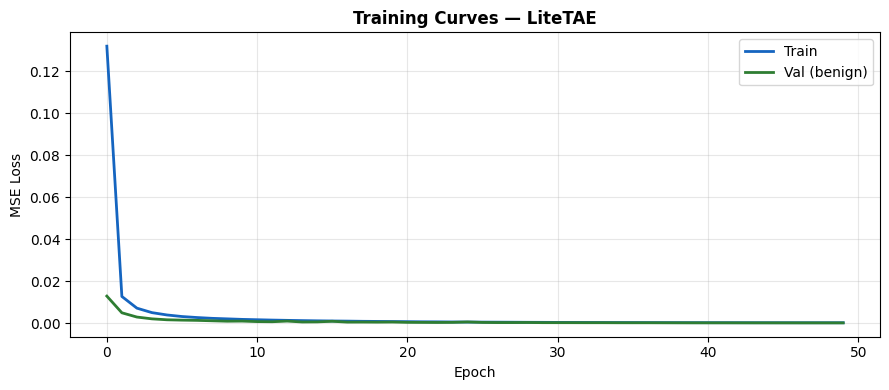

In [35]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train', color='#1565C0', lw=2)
ax.plot(val_losses,   label='Val (benign)', color='#2E7D32', lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Training Curves — LiteTAE', fontweight='bold')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=130)
plt.show()

In [140]:
@torch.no_grad()
def recon_errors(arr, bs=4096, top_k=2): 
    model.eval()
    errs = []
    t = torch.from_numpy(arr)
    for i in range(0, len(t), bs):
        xb = t[i:i+bs].to(DEVICE)
        r, _ = model(xb)
        
        per_feature_error = (r - xb)**2 
        
        top_errs, _ = torch.topk(per_feature_error, k=top_k, dim=1)
        e = top_errs.mean(dim=1).cpu().numpy()
        
        errs.append(e)
    return np.concatenate(errs)

print('Computing High-Resolution errors...')
e_bv = recon_errors(X_bv)   
e_av = recon_errors(X_av)   
e_bt = recon_errors(X_bt)   
e_at = recon_errors(X_at)

import pandas as pd
def smooth(e): return pd.Series(e).rolling(window=10, center=True, min_periods=1).mean().values

e_bv, e_av = smooth(e_bv), smooth(e_av)
e_bt, e_at = smooth(e_bt), smooth(e_at)

sep = e_av.mean() / (e_bv.mean() + 1e-9)
print(f'Separation ratio (Enhanced): {sep:.2f}x')

Computing High-Resolution errors...
Separation ratio (Enhanced): 11.18x


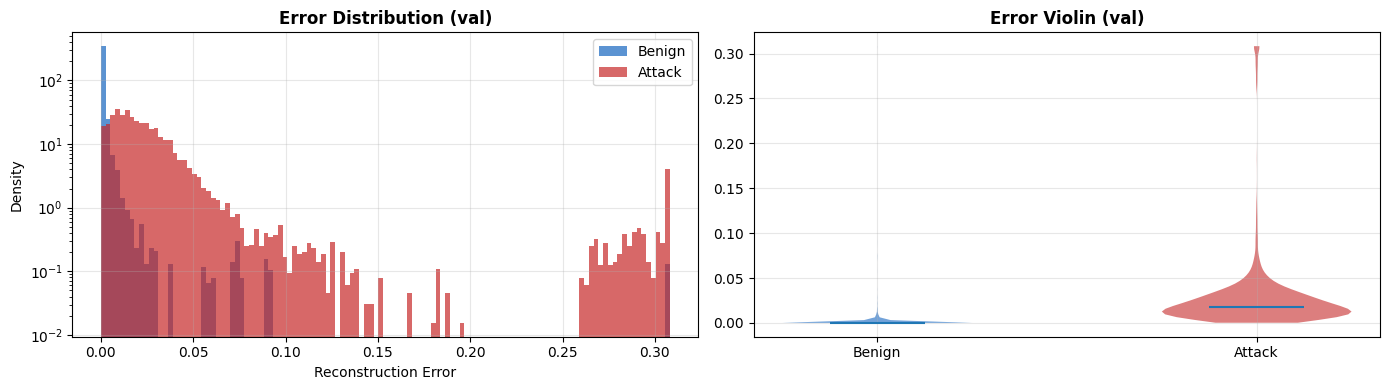

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
q99 = np.percentile(e_av, 99)
bins = np.linspace(0, q99, 120)
axes[0].hist(np.clip(e_bv, 0, q99), bins=bins, alpha=.7, density=True,
             color='#1565C0', label='Benign')
axes[0].hist(np.clip(e_av, 0, q99), bins=bins, alpha=.7, density=True,
             color='#C62828', label='Attack')
axes[0].set_xlabel('Reconstruction Error'); axes[0].set_ylabel('Density')
axes[0].set_title('Error Distribution (val)', fontweight='bold')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(alpha=.3)

# Violin
parts = axes[1].violinplot(
    [np.clip(e_bv, 0, q99), np.clip(e_av, 0, q99)],
    showmedians=True, showextrema=False
)
for pc, c in zip(parts['bodies'], ['#1565C0','#C62828']):
    pc.set_facecolor(c); pc.set_alpha(.6)
axes[1].set_xticks([1,2]); axes[1].set_xticklabels(['Benign','Attack'])
axes[1].set_title('Error Violin (val)', fontweight='bold')
axes[1].grid(alpha=.3)

plt.tight_layout()
plt.savefig('/kaggle/working/error_dist.png', dpi=130)
plt.show()

In [142]:
y_val = np.concatenate([np.zeros(len(e_bv)), np.ones(len(e_av))])
s_val = np.concatenate([e_bv, e_av])

fpr_r, tpr_r, thrs = roc_curve(y_val, s_val)
auc_val = roc_auc_score(y_val, s_val)

num_pos = np.sum(y_val) 
num_neg = np.sum(1 - y_val) 
total = len(y_val)

j_idx = np.argmax(tpr_r - fpr_r)
THR_B = thrs[j_idx]

pr_p, pr_r, pr_t = precision_recall_curve(y_val, s_val)
f1_arr = 2*pr_p*pr_r / (pr_p+pr_r+1e-9)
f1_idx = np.argmax(f1_arr)
THR_C  = pr_t[f1_idx]

acc_list = (tpr_r * num_pos + (1 - fpr_r) * num_neg) / total
max_acc_idx = np.argmax(acc_list)

THR_E = thrs[max_acc_idx]
MAX_ACC = acc_list[max_acc_idx]
TPR_E, FPR_E = tpr_r[max_acc_idx], fpr_r[max_acc_idx]
# ══════════════════════════════════════════════════════════════════

print(f'AUC-ROC (val) : {auc_val:.4f}')
print(f'Threshold B (Youden J)      : {THR_B:.6f}')
print(f'Threshold C (Best F1)       : {THR_C:.6f}')
print(f'Threshold E (MAX ACCURACY) : {THR_E:.6f}  →  Max Acc={MAX_ACC*100:.2f}%')
print(f'   Result at Max Acc        : TPR={TPR_E:.3f}, FPR={FPR_E:.4f}')

THRESHOLD = THR_E
print(f'\n FINAL CHOICE : Threshold E (Max Accuracy) = {THRESHOLD:.6f}')

AUC-ROC (val) : 0.9770
Threshold B (Youden J)      : 0.004164
Threshold C (Best F1)       : 0.004164
Threshold E (MAX ACCURACY) : 0.004644  →  Max Acc=93.05%
   Result at Max Acc        : TPR=0.906, FPR=0.0493

 FINAL CHOICE : Threshold E (Max Accuracy) = 0.004644


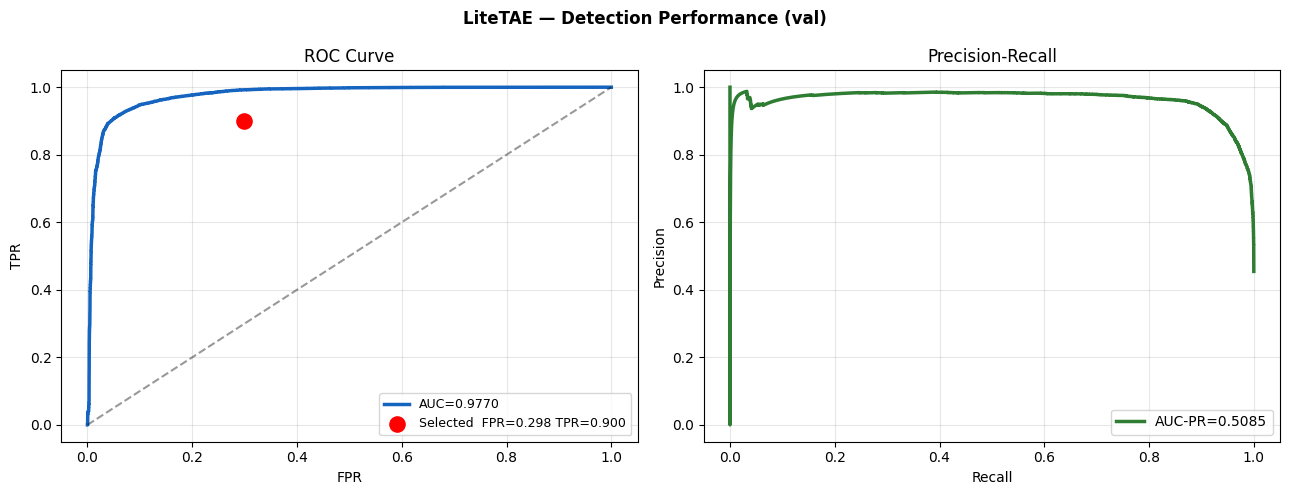

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr_r, tpr_r, '#1565C0', lw=2.5, label=f'AUC={auc_val:.4f}')
axes[0].plot([0,1],[0,1],'k--',alpha=.4)
axes[0].scatter([FPR_A],[TPR_A], color='red', s=120, zorder=5,
                label=f'Selected  FPR={FPR_A:.3f} TPR={TPR_A:.3f}')
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
axes[0].legend(fontsize=9); axes[0].grid(alpha=.3)

# PR
auc_pr = np.abs(np.trapz(pr_r[::-1], pr_p[::-1]))
axes[1].plot(pr_r, pr_p, '#2E7D32', lw=2.5, label=f'AUC-PR={auc_pr:.4f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall')
axes[1].legend(); axes[1].grid(alpha=.3)

plt.suptitle('LiteTAE — Detection Performance (val)', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/roc_pr.png', dpi=130)
plt.show()

In [144]:
y_test = np.concatenate([np.zeros(len(e_bt)), np.ones(len(e_at))])
s_test = np.concatenate([e_bt, e_at])
y_pred = (s_test >= THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

TPR = tp/(tp+fn+1e-9)
TNR = tn/(tn+fp+1e-9)
FPR = fp/(fp+tn+1e-9)
FNR = fn/(tp+fn+1e-9)
ACC = accuracy_score(y_test, y_pred)
PRE = precision_score(y_test, y_pred, zero_division=0)
F1  = f1_score(y_test, y_pred, zero_division=0)
AUC = roc_auc_score(y_test, s_test)

print('═'*52)
print('          FINAL TEST RESULTS — LiteTAE')
print('═'*52)
print(f'  Accuracy           : {ACC*100:6.2f}%')
print(f'  Precision          : {PRE*100:6.2f}%')
print(f'  F1 Score           : {F1*100:6.2f}%')
print(f'  AUC-ROC            : {AUC:.4f}')
print('─'*52)
print(f'   TPR (Recall)    : {TPR*100:6.2f}% ')
print(f'   TNR (Specificity): {TNR*100:6.2f}%')
print(f'    FPR             : {FPR*100:6.2f}% ')
print(f'    FNR             : {FNR*100:6.2f}%')
print('─'*52)
print(f'  TP={tp:,}  FP={fp:,}  TN={tn:,}  FN={fn:,}')
print('═'*52)

════════════════════════════════════════════════════
          FINAL TEST RESULTS — LiteTAE
════════════════════════════════════════════════════
  Accuracy           :  92.92%
  Precision          :  93.63%
  F1 Score           :  92.08%
  AUC-ROC            : 0.9762
────────────────────────────────────────────────────
   TPR (Recall)    :  90.58% 
   TNR (Specificity):  94.86%
    FPR             :   5.14% 
    FNR             :   9.42%
────────────────────────────────────────────────────
  TP=22,646  FP=1,541  TN=28,459  FN=2,354
════════════════════════════════════════════════════


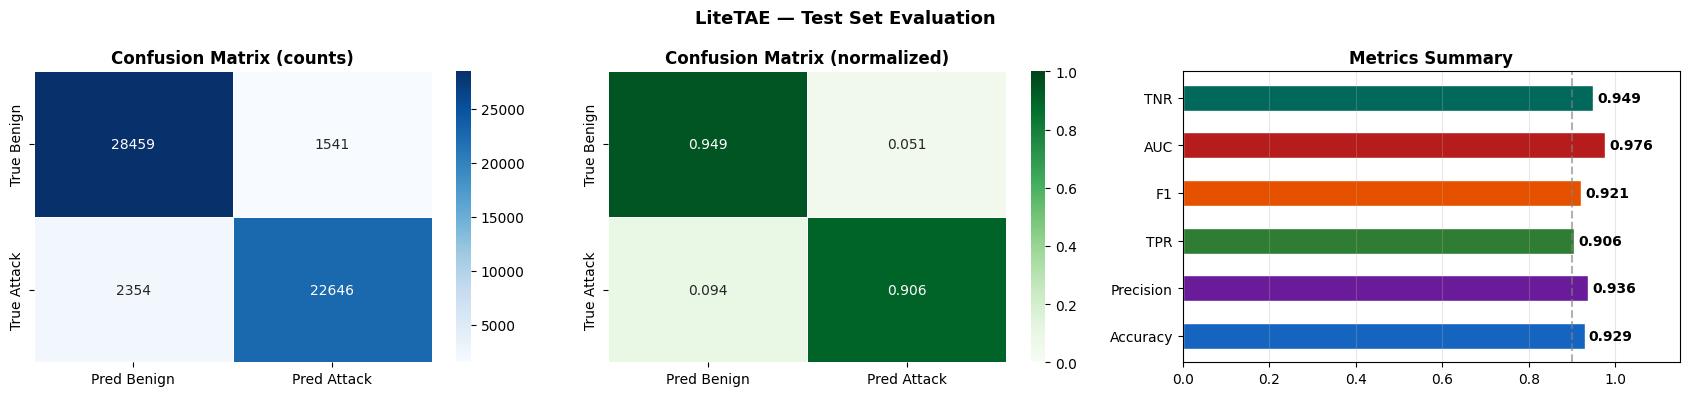

In [145]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

cm = np.array([[tn, fp],[fn, tp]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Benign','Pred Attack'],
            yticklabels=['True Benign','True Attack'],
            linewidths=.5)
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')

cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_n, annot=True, fmt='.3f', cmap='Greens', ax=axes[1],
            xticklabels=['Pred Benign','Pred Attack'],
            yticklabels=['True Benign','True Attack'],
            vmin=0, vmax=1, linewidths=.5)
axes[1].set_title('Confusion Matrix (normalized)', fontweight='bold')

mets = {'Accuracy': ACC, 'Precision': PRE, 'TPR': TPR,
        'F1': F1, 'AUC': AUC, 'TNR': TNR}
colors = ['#1565C0','#6A1B9A','#2E7D32','#E65100','#B71C1C','#00695C']
bars = axes[2].barh(list(mets.keys()), list(mets.values()),
                    color=colors, height=0.55, edgecolor='white')
for bar, v in zip(bars, mets.values()):
    axes[2].text(bar.get_width()+.01, bar.get_y()+bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=10, fontweight='bold')
axes[2].set_xlim(0, 1.15)
axes[2].axvline(.9, color='gray', ls='--', alpha=.6)
axes[2].set_title('Metrics Summary', fontweight='bold')
axes[2].grid(axis='x', alpha=.3)

plt.suptitle('LiteTAE — Test Set Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/evaluation.png', dpi=130)
plt.show()

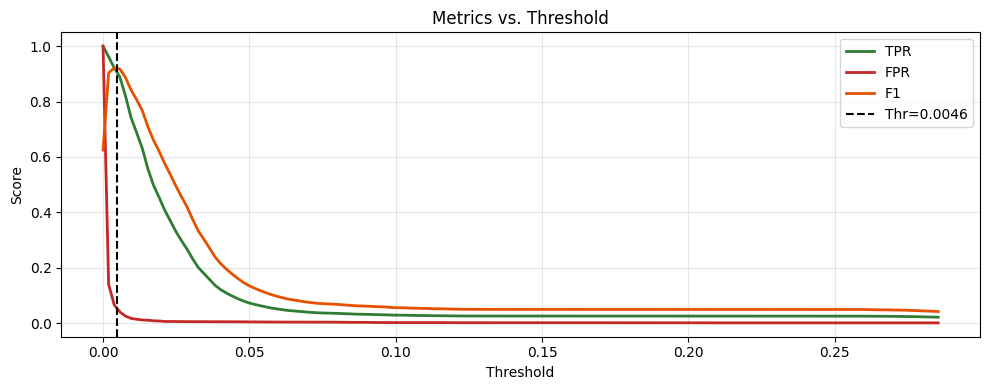

In [146]:
thr_range = np.linspace(s_test.min(), np.percentile(s_test, 99), 150)
tpr_l, fpr_l, f1_l = [], [], []

for t in thr_range:
    p = (s_test >= t).astype(int)
    cm_t = confusion_matrix(y_test, p)
    if cm_t.shape == (2,2):
        _tn,_fp,_fn,_tp = cm_t.ravel()
        tpr_l.append(_tp/(_tp+_fn+1e-9))
        fpr_l.append(_fp/(_fp+_tn+1e-9))
        f1_l.append(f1_score(y_test, p, zero_division=0))
    else:
        tpr_l.append(0); fpr_l.append(0); f1_l.append(0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thr_range, tpr_l, '#2E7D32', lw=2, label='TPR')
ax.plot(thr_range, fpr_l, '#C62828', lw=2, label='FPR')
ax.plot(thr_range, f1_l,  '#E65100', lw=2, label='F1')
ax.axvline(THRESHOLD, color='black', ls='--', lw=1.5,
           label=f'Thr={THRESHOLD:.4f}')
ax.set(xlabel='Threshold', ylabel='Score',
       title='Metrics vs. Threshold')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig('/kaggle/working/threshold_sensitivity.png', dpi=130)
plt.show()

In [147]:
torch.save({
    'state_dict' : model.state_dict(),
    'config'     : CFG,
    'input_dim'  : INPUT_DIM,
    'threshold'  : float(THRESHOLD),
    'feat_cols'  : FEAT_COLS,
    'scaler_c'   : scaler.center_.tolist(),
    'scaler_s'   : scaler.scale_.tolist(),
    'metrics'    : dict(TPR=TPR, FPR=FPR, TNR=TNR, F1=F1, AUC=AUC, ACC=ACC)
}, '/kaggle/working/lite_tae_full.pt')

results = dict(
    model='LiteTAE', dataset='CSE-CIC-IDS2018',
    threshold=float(THRESHOLD),
    metrics=dict(
        accuracy=round(ACC,4), precision=round(PRE,4),
        recall_tpr=round(TPR,4), f1=round(F1,4),
        auc_roc=round(AUC,4), fpr=round(FPR,4),
        TP=int(tp), FP=int(fp), TN=int(tn), FN=int(fn)
    )
)
with open('/kaggle/working/results.json','w') as f:
    json.dump(results, f, indent=2)

print('Saved:')
print('  /kaggle/working/lite_tae_full.pt')
print('  /kaggle/working/results.json')
print()
print(json.dumps(results, indent=2))

Saved:
  /kaggle/working/lite_tae_full.pt
  /kaggle/working/results.json

{
  "model": "LiteTAE",
  "dataset": "CSE-CIC-IDS2018",
  "threshold": 0.004644227369135478,
  "metrics": {
    "accuracy": 0.9292,
    "precision": 0.9363,
    "recall_tpr": 0.9058,
    "f1": 0.9208,
    "auc_roc": 0.9762,
    "fpr": 0.0514,
    "TP": 22646,
    "FP": 1541,
    "TN": 28459,
    "FN": 2354
  }
}
